In [61]:
import pandas as pd
import sklearn.metrics as skm
import matplotlib.pyplot as plt

## Context-based results
### Qwen2.5-VL-3B

In [62]:
q25 = pd.read_csv("qwen2.5_labeled.csv", index_col=0)
q25.head()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
0,mscoco/images/COCO_train2014_000000462955.jpg,Peace,0.3,0.6,0.8,42,32,413,472,emotic/emotic/images/mscoco/images/COCO_train2...,Engagement,Engagement
1,mscoco/images/COCO_train2014_000000186198.jpg,Peace,0.7,0.7,0.8,336,80,494,327,emotic/emotic/images/mscoco/images/COCO_train2...,Excitement,Excitement
2,mscoco/images/COCO_val2014_000000122997.jpg,Peace,0.6,0.4,0.7,141,47,348,343,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Engagement
3,mscoco/images/COCO_train2014_000000253959.jpg,Peace,0.7,0.8,0.2,73,276,276,493,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Happiness
4,mscoco/images/COCO_val2014_000000461715.jpg,Peace,0.7,0.4,0.7,90,27,300,355,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Pleasure


In [63]:
1 / len(q25.label.unique()) # random choice accuracy

0.038461538461538464

Accuracy:  0.149
Precision:  0.18328417533835312
Recall:  0.13084871091361386
F1 Score:  0.11397193152884137


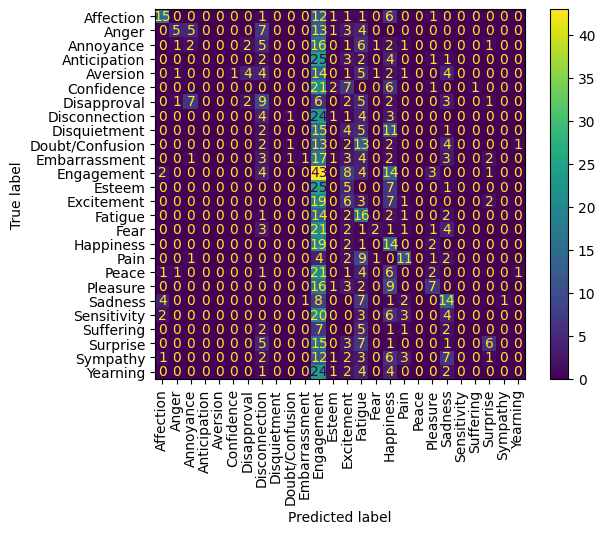

In [64]:
y_true = q25.label
y_pred = q25.img_label

print("Accuracy: ", skm.accuracy_score(y_true, y_pred))
print("Precision: ", skm.precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall: ", skm.recall_score(y_true, y_pred, average="macro"))
print("F1 Score: ", skm.f1_score(y_true, y_pred, average="macro"))
skm.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation="vertical")
plt.show()

### Qwen2-VL-7B-Instruct

In [65]:
q2 = pd.read_csv("qwen2_labeled.csv", index_col=0)
q2.head()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
0,mscoco/images/COCO_train2014_000000462955.jpg,Peace,0.3,0.6,0.8,42,32,413,472,emotic/emotic/images/mscoco/images/COCO_train2...,Embarrassment,Confidence
1,mscoco/images/COCO_train2014_000000186198.jpg,Peace,0.7,0.7,0.8,336,80,494,327,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Excitement
2,mscoco/images/COCO_val2014_000000122997.jpg,Peace,0.6,0.4,0.7,141,47,348,343,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Engagement
3,mscoco/images/COCO_train2014_000000253959.jpg,Peace,0.7,0.8,0.2,73,276,276,493,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Surprise
4,mscoco/images/COCO_val2014_000000461715.jpg,Peace,0.7,0.4,0.7,90,27,300,355,emotic/emotic/images/mscoco/images/COCO_val201...,Yearning,Doubt/Confusion


Accuracy:  0.15
Precision:  0.18285453299410956
Recall:  0.13734852016439683
F1 Score:  0.11456454478527148


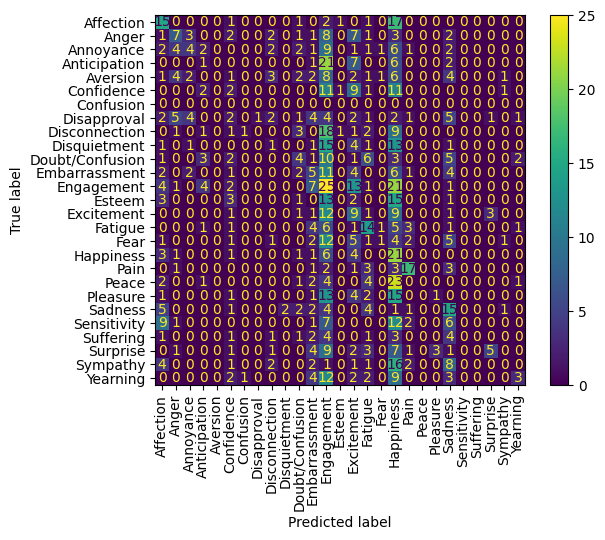

In [66]:
y_true = q2.label
y_pred = q2.img_label

print("Accuracy: ", skm.accuracy_score(y_true, y_pred))
print("Precision: ", skm.precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall: ", skm.recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 Score: ", skm.f1_score(y_true, y_pred, average="macro"))
skm.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation="vertical")
plt.show()

### Llama 3.2 Vision 11B

In [67]:
llama = pd.read_csv("llama_labeled.csv", index_col=0)
llama.head()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
0,mscoco/images/COCO_train2014_000000462955.jpg,Peace,0.3,0.6,0.8,42,32,413,472,emotic/emotic/images/mscoco/images/COCO_train2...,Confidence,Confidence
1,mscoco/images/COCO_train2014_000000186198.jpg,Peace,0.7,0.7,0.8,336,80,494,327,emotic/emotic/images/mscoco/images/COCO_train2...,Excitement,Excitement
2,mscoco/images/COCO_val2014_000000122997.jpg,Peace,0.6,0.4,0.7,141,47,348,343,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Engagement
3,mscoco/images/COCO_train2014_000000253959.jpg,Peace,0.7,0.8,0.2,73,276,276,493,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Surprise
4,mscoco/images/COCO_val2014_000000461715.jpg,Peace,0.7,0.4,0.7,90,27,300,355,emotic/emotic/images/mscoco/images/COCO_val201...,Happiness,Pleasure


In [68]:
# remove problematic labels
labels = llama.label.unique()
valid = llama.loc[llama.img_label.isin(labels)]
valid.shape # removed 21 bad labels

(979, 12)

Accuracy:  0.11440245148110317
Precision:  0.14289765239820787
Recall:  0.11584672237551344
F1 Score:  0.10113645158435006


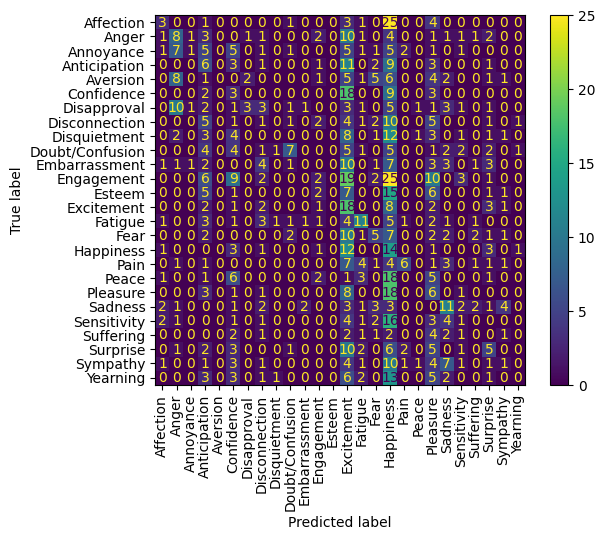

In [69]:
y_true = valid.label
y_pred = valid.img_label

print("Accuracy: ", skm.accuracy_score(y_true, y_pred))
print("Precision: ", skm.precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall: ", skm.recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 Score: ", skm.f1_score(y_true, y_pred, average="macro"))
skm.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation="vertical")
plt.show()

## Cropped image results
### Qwen2.5-VL-3B

In [70]:
df = pd.read_csv("qwen2.5_labeled.csv", index_col=0)
df.head()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
0,mscoco/images/COCO_train2014_000000462955.jpg,Peace,0.3,0.6,0.8,42,32,413,472,emotic/emotic/images/mscoco/images/COCO_train2...,Engagement,Engagement
1,mscoco/images/COCO_train2014_000000186198.jpg,Peace,0.7,0.7,0.8,336,80,494,327,emotic/emotic/images/mscoco/images/COCO_train2...,Excitement,Excitement
2,mscoco/images/COCO_val2014_000000122997.jpg,Peace,0.6,0.4,0.7,141,47,348,343,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Engagement
3,mscoco/images/COCO_train2014_000000253959.jpg,Peace,0.7,0.8,0.2,73,276,276,493,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Happiness
4,mscoco/images/COCO_val2014_000000461715.jpg,Peace,0.7,0.4,0.7,90,27,300,355,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Pleasure


Accuracy:  0.134
Precision:  0.1644470470385004
Recall:  0.11426297090424233
F1 Score:  0.09578909272522235


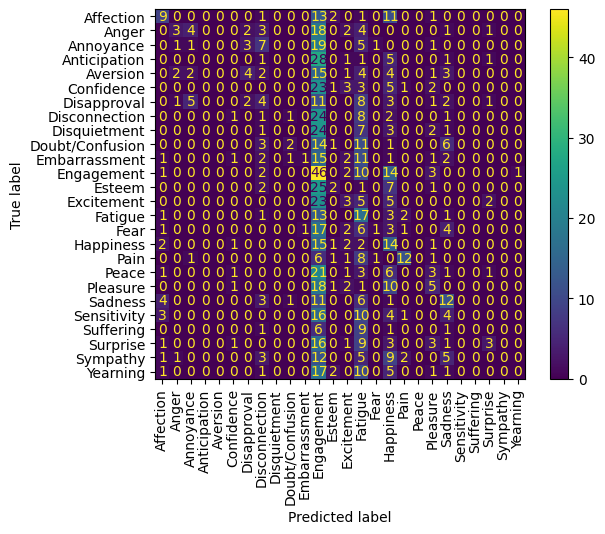

In [71]:
y_true = df.label
y_pred = df.crop_label

print("Accuracy: ", skm.accuracy_score(y_true, y_pred))
print("Precision: ", skm.precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall: ", skm.recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 Score: ", skm.f1_score(y_true, y_pred, average="macro"))
skm.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation="vertical")
plt.show()

### Qwen2-VL-7B-Instruct 

In [72]:
df = pd.read_csv("qwen2_labeled.csv", index_col=0)
df.head()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
0,mscoco/images/COCO_train2014_000000462955.jpg,Peace,0.3,0.6,0.8,42,32,413,472,emotic/emotic/images/mscoco/images/COCO_train2...,Embarrassment,Confidence
1,mscoco/images/COCO_train2014_000000186198.jpg,Peace,0.7,0.7,0.8,336,80,494,327,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Excitement
2,mscoco/images/COCO_val2014_000000122997.jpg,Peace,0.6,0.4,0.7,141,47,348,343,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Engagement
3,mscoco/images/COCO_train2014_000000253959.jpg,Peace,0.7,0.8,0.2,73,276,276,493,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Surprise
4,mscoco/images/COCO_val2014_000000461715.jpg,Peace,0.7,0.4,0.7,90,27,300,355,emotic/emotic/images/mscoco/images/COCO_val201...,Yearning,Doubt/Confusion


Accuracy:  0.135
Precision:  0.15733597765106885
Recall:  0.12245440514766341
F1 Score:  0.09607918127245739


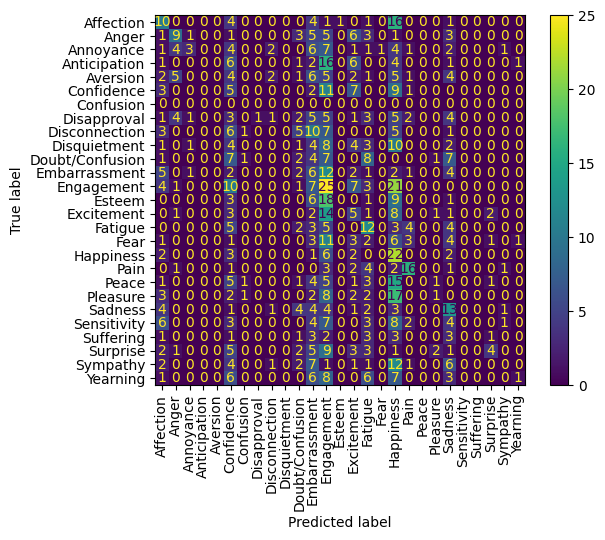

In [73]:
y_true = df.label
y_pred = df.crop_label

print("Accuracy: ", skm.accuracy_score(y_true, y_pred))
print("Precision: ", skm.precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall: ", skm.recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 Score: ", skm.f1_score(y_true, y_pred, average="macro"))
skm.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation="vertical")
plt.show()

### Llama 3.2 Vision 11B

In [74]:
df = pd.read_csv("llama_labeled.csv", index_col=0)
df.head()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
0,mscoco/images/COCO_train2014_000000462955.jpg,Peace,0.3,0.6,0.8,42,32,413,472,emotic/emotic/images/mscoco/images/COCO_train2...,Confidence,Confidence
1,mscoco/images/COCO_train2014_000000186198.jpg,Peace,0.7,0.7,0.8,336,80,494,327,emotic/emotic/images/mscoco/images/COCO_train2...,Excitement,Excitement
2,mscoco/images/COCO_val2014_000000122997.jpg,Peace,0.6,0.4,0.7,141,47,348,343,emotic/emotic/images/mscoco/images/COCO_val201...,Engagement,Engagement
3,mscoco/images/COCO_train2014_000000253959.jpg,Peace,0.7,0.8,0.2,73,276,276,493,emotic/emotic/images/mscoco/images/COCO_train2...,Happiness,Surprise
4,mscoco/images/COCO_val2014_000000461715.jpg,Peace,0.7,0.4,0.7,90,27,300,355,emotic/emotic/images/mscoco/images/COCO_val201...,Happiness,Pleasure


In [75]:
# remove problematic labels
labels = df.label.unique()
df = df.loc[df.crop_label.isin(labels)]
df.shape # removed 18 bad labels

(982, 12)

Accuracy:  0.10386965376782077
Precision:  0.134327001692416
Recall:  0.10721603885082874
F1 Score:  0.087702817537308


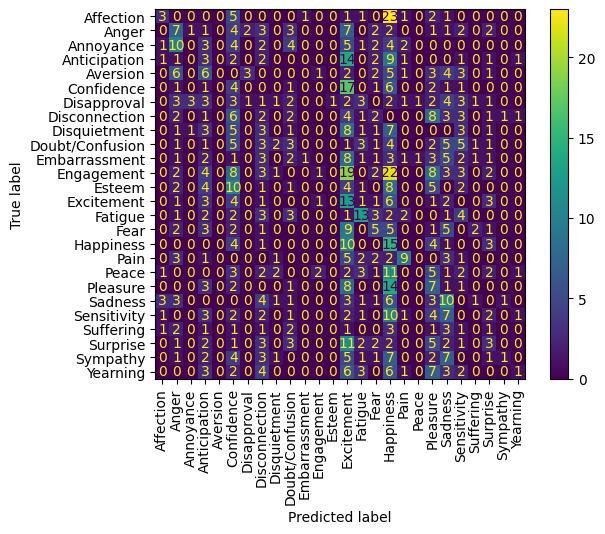

In [76]:
y_true = df.label
y_pred = df.crop_label

print("Accuracy: ", skm.accuracy_score(y_true, y_pred))
print("Precision: ", skm.precision_score(y_true, y_pred, average="macro", zero_division=0))
print("Recall: ", skm.recall_score(y_true, y_pred, average="macro", zero_division=0))
print("F1 Score: ", skm.f1_score(y_true, y_pred, average="macro"))
skm.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, xticks_rotation="vertical")
plt.show()

## Extra analysis

In [89]:
import PIL.Image

In [85]:
df = pd.read_csv("qwen2_labeled.csv", index_col=0)

In [ ]:
# find a case where context helped
helped = df[(df.img_label == df.label) & (df.crop_label != df.label)]

row = helped.sample().iloc[0]
fullpath = f"emotic/images/{row.image_path}"
img = PIL.Image.open(fullpath)

plt.imshow(img)
plt.title(f"Correctly labeled as {row.label} with context")
plt.show()

crop = img.crop((row.bbox_x1, row.bbox_y1, row.bbox_x2, row.bbox_y2))
plt.imshow(crop)
plt.title(f"Incorrectly labeled {row.label} as {row.crop_label} when cropped")
plt.show()

,image_path,label,valence,arousal,dominance,bbox_x1,bbox_y1,bbox_x2,bbox_y2,fullpath,img_label,crop_label
46,emodb_small/images/007eear5kx5qhbzewz.jpg,Affection,0.8,0.4,1.0,215,111,580,352,emotic/emotic/images/emodb_small/images/007eea...,Affection,Happiness
51,emodb_small/images/2dx6iyafrj0xqsbyxz.jpg,Affection,0.6,0.6,0.7,126,36,274,183,emotic/emotic/images/emodb_small/images/2dx6iy...,Affection,Sadness
60,mscoco/images/COCO_val2014_000000243148.jpg,Affection,0.7,0.4,0.7,129,72,480,355,emotic/emotic/images/mscoco/images/COCO_val201...,Affection,Embarrassment
67,framesdb/images/frame_cayeoa053pjmm6w5.jpg,Affection,0.5,0.2,0.9,656,88,795,495,emotic/emotic/images/framesdb/images/frame_cay...,Affection,Confidence
68,framesdb/images/frame_cayeoa053pjmm6w5.jpg,Affection,0.6,0.2,0.9,21,116,158,471,emotic/emotic/images/framesdb/images/frame_cay...,Affection,Happiness
